# Sivers: azimuthal-acceptance comparison

The SoLID 3He (neutron) Sivers fit across **five** pseudodata configurations, all
generated in this repo and all fitted at 500 replicas, against the world-data fit
as the reference. The Sivers counterpart of `plot-transversity_phicompare.ipynb`;
the physics machinery (`f1tcalcorr`, `tmd.f1Tperp1`, the
$xf_{1T}^{\perp(1)}$ observable) is unchanged.

| key | run directory | acceptance | binning | bins |
|---|---|---|---|---|
| `world` | `../data_other` | existing world data — **the reference** | — | 234 rows |
| `sbs` | `../data_other` | SBS projection — a second external reference, **stat-only panel** | — | 455 rows |
| `phifull` | `data_phifull` | full 2π (100%) | own | 1660 |
| `phi4seg_fullbin` | `data_phi4seg24deg_phifullbin` | 4 × 24° (26.7% nominal), both arms | **reused from `phifull`** | 1660 |
| `phi4seg` | `data_phi4seg24deg` | 4 × 24°, both arms | own | 169 |
| `phi4segFA_fullbin` | `data_phi4seg24degFA_phifullbin` | 4 × 24°, **forward angle only** (large-angle e⁻ keeps full 2π) | **reused from `phifull`** | 1660 |
| `phi4segFA` | `data_phi4seg24degFA` | 4 × 24°, forward angle only | own | 239 |

The `*_fullbin` runs share `phifull`'s bins, so they pair 1:1 with it and with
each other — those are the ones to compare. The own-bins runs re-binned under
their own acceptance, trading fewer bins for more events in each, which makes
them look better at equal acceptance for reasons of bin width rather than physics.

**The nominal coverage is not the event cost.** The cut applies to the electron
and the hadron alike, so a coincidence survives roughly 26.7² ≈ 7.1%; measured,
the median surviving yield is 4.8%. See `README.md` in this directory.

*(Rewritten 2026-08-31: the previous version read `output*` directories and
`tmdlib.tmd` from the upstream tree, and covered 6×24° and 4×12°FA
configurations that do not exist here.)*

**SBS is a reference, not a SoLID configuration.** It is an external projection with no systematics model of its own, so there is a single SBS fit rather than a stat/syst pair, and it is drawn in the **stat-only panel only** — absent from every stat+syst panel and table rather than repeated there unchanged. Fitted at 500 replicas like everything else, so its 3.2% replica-sampling noise is the same as the rest.


In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

sys.path.insert(0, os.path.abspath('..'))   # tmd.py lives at the repo root
import tmd

GALLERY = 'gallery'
os.makedirs(GALLERY, exist_ok=True)

Q2  = 2.4
tol = 1.5    # Sivers value (the transversity notebook uses 7.04); it cancels in
             # every error RATIO below, so the comparisons do not depend on it

LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/CJ15lo/CJ15lo_0000.dat
CJ15lo PDF set, member #0, version 2; LHAPDF ID = 12300
LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/DSSFFlo/DSSFFlo_0211.dat
DSSFFlo PDF set, member #211, version 1; LHAPDF ID = 90211
LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/DSSFFlo/DSSFFlo_0321.dat
DSSFFlo PDF set, member #321, version 1; LHAPDF ID = 90321
LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/NNPDFpol11_100/NNPDFpol11_100_0000.dat
NNPDFpol11_100 PDF set, member #0, version 1; LHAPDF ID = 251000


## Load fit results

Each file is the raw per-replica parameter table (50 rows x `Nu,au,bu,cu,Nd,ad,bd,cd,Nub,Ndb,kt2,chi2`).

In [2]:
STAT, SYST = 'out-enhanced3he_sivers.dat', 'out-enhanced3hesyst_sivers.dat'

# REF is the denominator of every error ratio below.
# The R1 < 0.3 fits, derived from STAT/SYST rather than spelled out, so a
# change to the amplitude or the file naming carries through to both.
STAT_R1, SYST_R1 = (v.replace('.dat', '_r1lt0.3.dat') for v in (STAT, SYST))

REF = 'world'

RUNS = {
    'world':             {'dir': '../data_other',
                          # the world fit has no stat/syst variants -- the same
                          # fit is the reference in both panels
                          'files': {'': 'out-world_sivers.dat', 'syst': 'out-world_sivers.dat'},
                          'label': r'$\rm world~data$',
                          'color': 'gray'},
    'sbs':               {'dir': '../data_other',
                          # one fit, no stat/syst split: no 'syst' key, so
                          # runs_for() leaves SBS out of every stat+syst panel.
                          'files': {'': 'out-sbs_sivers.dat'},
                          'label': r'$\rm SBS$',
                          'color': 'saddlebrown'},
    # The same SBS fit restricted to R1 < 0.3. Like 'sbs' above it has no
    # 'syst' key -- SBS carries no systematics model at all -- so runs_for()
    # keeps both SBS curves out of every stat+syst panel.
    'sbs_tmd':           {'dir': '../data_other',
                          'files': {'': 'out-sbs_sivers_r1lt0.3.dat'},
                          'label': r'$\rm SBS~(R_1<0.3)$',
                          'color': 'peru'},
    'phifull':           {'dir': 'data_phifull',
                          'files': {'': STAT, 'syst': SYST},
                          'label': r'$\rm SoLID~full~2\pi$',
                          'color': 'black'},
    # Same run and same bins as above; the fit saw only the rows with
    # collinearity R1 < 0.3 (fit --tmdcut, the 2022 affinity paper's TMD
    # boundary). Any gap to its uncut twin is what that cut costs.
    'phifull_tmd':         {'dir': 'data_phifull',
                          'files': {'': STAT_R1, 'syst': SYST_R1},
                          'label': r'$\rm SoLID~2\pi~(R_1<0.3)$',
                          'color': 'red'},
    'phi4seg_fullbin':   {'dir': 'data_phi4seg24deg_phifullbin',
                          'files': {'': STAT, 'syst': SYST},
                          'label': r'$\rm 4\times24^\circ~(2\pi~bins)$',
                          'color': 'green'},
    'phi4seg_fullbin_tmd': {'dir': 'data_phi4seg24deg_phifullbin',
                          'files': {'': STAT_R1, 'syst': SYST_R1},
                          'label': r'$\rm 4\times24^\circ~(2\pi~bins,~R_1<0.3)$',
                          'color': 'limegreen'},
    'phi4seg':           {'dir': 'data_phi4seg24deg',
                          'files': {'': STAT, 'syst': SYST},
                          'label': r'$\rm 4\times24^\circ~(own~bins)$',
                          'color': 'darkorange'},
    'phi4seg_tmd':         {'dir': 'data_phi4seg24deg',
                          'files': {'': STAT_R1, 'syst': SYST_R1},
                          'label': r'$\rm 4\times24^\circ~(own~bins,~R_1<0.3)$',
                          'color': 'gold'},
    # Same 4x24 deg acceptance as the two entries above; only the BINNING differs.
    # 806 bins from make_bins_from_count.py over an opt-4 count table taken under
    # the phi cut, against 1660 reused from phifull and 169 of its own. Its
    # statistical error matches the 1660-bin run to 0.8% while the 169-bin run is
    # 15% worse, which is what puts saturation below ~800 -- see README.md.
    'phi4seg_countbin':  {'dir': 'data_phi4seg24deg_countbin800',
                          'files': {'': STAT, 'syst': SYST},
                          'label': r'$\rm 4\times24^\circ~(count~bins,~806)$',
                          'color': 'teal'},
}
# 'sbs' is an external projection with no systematics model of its own: there is
# one SBS fit, not a stat/syst pair, so it belongs in the stat-only panel and
# nowhere else. The mechanism is the absence of a 'syst' entry in its `files` --
# every loop below iterates runs_for(suffix), so each run appears in exactly the
# panels it has a fit for. 'world' is the reference (the denominator of every
# ratio) and so carries both, pointing at the same file twice.
def runs_for(suffix):
    return [(run, cfg) for run, cfg in RUNS.items() if suffix in cfg['files']]

VARIANTS = ['', 'syst']

par = {}
for run, cfg in RUNS.items():
    for suf in VARIANTS:
        if suf not in cfg['files']:
            print(f'{run+suf:22s} {"-- no fit; absent from this panel":52s}')
            continue
        path = os.path.join(cfg['dir'], cfg['files'][suf])
        par[run + suf] = pd.read_csv(path, sep=r'\s+', index_col=False)
        print(f'{run+suf:22s} {path:52s} {len(par[run+suf])} replicas')

world                  ../data_other/out-world_sivers.dat                   500 replicas
worldsyst              ../data_other/out-world_sivers.dat                   500 replicas
sbs                    ../data_other/out-sbs_sivers.dat                     500 replicas
sbssyst                -- no fit; absent from this panel                   
sbs_tmd                ../data_other/out-sbs_sivers_r1lt0.3.dat             500 replicas
sbs_tmdsyst            -- no fit; absent from this panel                   
phifull                data_phifull/out-enhanced3he_sivers.dat              500 replicas
phifullsyst            data_phifull/out-enhanced3hesyst_sivers.dat          500 replicas
phifull_tmd            data_phifull/out-enhanced3he_sivers_r1lt0.3.dat      500 replicas
phifull_tmdsyst        data_phifull/out-enhanced3hesyst_sivers_r1lt0.3.dat  500 replicas
phi4seg_fullbin        data_phi4seg24deg_phifullbin/out-enhanced3he_sivers.dat 500 replicas
phi4seg_fullbinsyst    data_phi4seg24deg_phi

phi4seg_fullbin_tmd    data_phi4seg24deg_phifullbin/out-enhanced3he_sivers_r1lt0.3.dat 500 replicas
phi4seg_fullbin_tmdsyst data_phi4seg24deg_phifullbin/out-enhanced3hesyst_sivers_r1lt0.3.dat 500 replicas
phi4seg                data_phi4seg24deg/out-enhanced3he_sivers.dat         500 replicas
phi4segsyst            data_phi4seg24deg/out-enhanced3hesyst_sivers.dat     500 replicas
phi4seg_tmd            data_phi4seg24deg/out-enhanced3he_sivers_r1lt0.3.dat 500 replicas
phi4seg_tmdsyst        data_phi4seg24deg/out-enhanced3hesyst_sivers_r1lt0.3.dat 500 replicas
phi4seg_countbin       data_phi4seg24deg_countbin800/out-enhanced3he_sivers.dat 500 replicas
phi4seg_countbinsyst   data_phi4seg24deg_countbin800/out-enhanced3hesyst_sivers.dat 500 replicas


### Fitted parameters, run by run

In [3]:
rows = []
for key, p in par.items():
    r = {'run': key}
    for c in p.columns:
        r[c] = f'{p[c].mean():.4f} +- {p[c].std():.4f}'
    rows.append(r)
pd.set_option('display.width', 250)
partable = pd.DataFrame(rows).set_index('run')
partable[['Nu', 'au', 'bu', 'Nd', 'ad', 'bd', 'kt2', 'chi2']]

,Nu,au,bu,Nd,ad,bd,kt2,chi2
run,,,,,,,,
world,-0.0387 +- 0.0019,0.6663 +- 0.1130,4.1564 +- 1.0440,0.0576 +- 0.0154,0.4381 +- 0.2504,3.8314 +- 3.1709,0.1592 +- 0.0300,226.1234 +- 20.8210
worldsyst,-0.0387 +- 0.0019,0.6663 +- 0.1130,4.1564 +- 1.0440,0.0576 +- 0.0154,0.4381 +- 0.2504,3.8314 +- 3.1709,0.1592 +- 0.0300,226.1234 +- 20.8210
sbs,-0.0357 +- 0.0081,0.6078 +- 0.0642,4.2252 +- 1.0423,0.0470 +- 0.0088,0.3318 +- 0.0861,3.4107 +- 0.7871,0.1591 +- 0.0150,449.2308 +- 30.6505
sbs_tmd,-0.0353 +- 0.0077,0.6096 +- 0.0665,4.2939 +- 0.9853,0.0476 +- 0.0088,0.3386 +- 0.0835,3.3611 +- 0.9450,0.1595 +- 0.0134,314.8765 +- 25.2520
phifull,-0.0374 +- 0.0064,0.6315 +- 0.0472,4.1441 +- 0.8068,0.0499 +- 0.0051,0.3714 +- 0.0485,3.3170 +- 0.5645,0.1600 +- 0.0016,1650.3382 +- 56.9493
phifullsyst,-0.0373 +- 0.0066,0.6277 +- 0.0475,4.1453 +- 0.8341,0.0497 +- 0.0057,0.3633 +- 0.0589,3.3128 +- 0.6192,0.1600 +- 0.0038,1650.6999 +- 56.9243
phifull_tmd,-0.0365 +- 0.0067,0.6239 +- 0.0583,4.2314 +- 0.8204,0.0499 +- 0.0056,0.3674 +- 0.0617,3.3048 +- 0.6016,0.1599 +- 0.0056,919.9732 +- 44.7559
phifull_tmdsyst,-0.0364 +- 0.0071,0.6198 +- 0.0610,4.2234 +- 0.8544,0.0499 +- 0.0064,0.3628 +- 0.0654,3.2735 +- 0.6726,0.1598 +- 0.0094,920.4182 +- 44.7780
phi4seg_fullbin,-0.0350 +- 0.0093,0.5979 +- 0.0870,4.3763 +- 1.1593,0.0486 +- 0.0081,0.3482 +- 0.0723,3.4120 +- 0.9666,0.1604 +- 0.0065,1652.2206 +- 56.9074


## Calculate $xf_{1T}^{\perp(1)}(x)$

Follows `f1tcalc()` in `plot-sivers.ipynb`: for each $x$, evaluate
`tmd.f1Tperp1` once per replica using that replica's own parameters, take the
valence combination $q - \bar q$, then central value = mean, error = `tol` × std.

(`Nub`/`Ndb` are fixed to 0 in `fitsim`, so the $\bar q$ terms vanish — the
subtraction is kept for fidelity with the reference notebook.)

In [4]:
def f1tcalcorr(pset, Q2, tol):
    rows = []
    X = np.linspace(1e-3, 1, 200)
    pset = pset.reset_index(drop=True)
    for x in X:
        # errors only -- central values are untouched. Identically 1 for x <= 0.4,
        # exp(-6.8*(x-0.4)^2) above: x0.76 at x=0.6, x0.34 at x=0.8, x0.09 at x=1.
        corr = np.exp(-1.7 * (np.abs(x - 0.4) + x - 0.4)**2)
        xu, xd = [], []
        for i in range(len(pset)):
            f1t = tmd.f1Tperp1(x, Q2, 'proton', pset.loc[i])
            xu.append(x * (f1t[2] - f1t[-2]))
            xd.append(x * (f1t[1] - f1t[-1]))
        rows.append({'x': x,
                     'xu': np.mean(xu), 'Exu': tol * np.std(xu) * corr,
                     'xd': np.mean(xd), 'Exd': tol * np.std(xd) * corr})
    return pd.DataFrame(rows)

In [5]:
%%time
f1t = {}
for key in par:
    f1t[key] = f1tcalcorr(par[key], Q2, tol)
    print('done', key)

done world


done worldsyst


done sbs


done sbs_tmd


done phifull


...

done phi4segsyst


done phi4seg_tmd


done phi4seg_tmdsyst


done phi4seg_countbin


done phi4seg_countbinsyst
CPU times: user 2min 39s, sys: 576 ms, total: 2min 39s
Wall time: 2min 41s


## $xf_{1T}^{\perp(1)}(x)$ bands, three runs overlaid

Top panel: $u$ (solid) and $d$ (dashed) Sivers first-moment bands. Bottom panel:
each φ-cut run's uncertainty relative to the full-2π baseline — above 1 means
the φ cut degrades the projection. `tol` cancels in the bottom panel.

In [6]:
def band_plot(suffix, fname, title):
    fig = plt.figure(figsize=(6.5, 10))

    ax = fig.add_subplot(2, 1, 1)
    for run, cfg in runs_for(suffix):
        d = f1t[run + suffix]
        ax.fill_between(d['x'], d['xu'] - d['Exu'], d['xu'] + d['Exu'],
                        color=cfg['color'], alpha=0.30, linewidth=0)
        ax.fill_between(d['x'], d['xd'] - d['Exd'], d['xd'] + d['Exd'],
                        color=cfg['color'], alpha=0.30, linewidth=0)
        ax.plot(d['x'], d['xu'], color=cfg['color'], linewidth=1.2, label=cfg['label'])
        ax.plot(d['x'], d['xd'], color=cfg['color'], linewidth=1.2, linestyle='--')
    ax.axhline(y=0, linestyle='-', color='black', alpha=0.9, linewidth=1)
    ax.axvline(x=0.05, linestyle='--', color='black', alpha=0.7, linewidth=1)
    ax.axvline(x=0.60, linestyle='--', color='black', alpha=0.7, linewidth=1)
    ax.set_ylabel(r'$xf_{1T}^{\perp(1)}(x)$', size=25)
    ax.set_xlim(0, 0.7)
    ax.set_ylim(-0.042, 0.05)
    ax.set_xticklabels([])
    ax.tick_params(axis='both', which='both', direction='in', labelsize=20)
    ax.text(0.5, 0.96, title, horizontalalignment='center', verticalalignment='center',
            transform=ax.transAxes, fontsize=17)
    ax.text(0.03, 0.10, r'$u\rm~solid,~d~dashed$', transform=ax.transAxes, fontsize=15)
    ax.legend(loc='lower right', frameon=False, fontsize=13)

    ax = fig.add_subplot(2, 1, 2)
    ref = f1t[REF + suffix]
    for run, cfg in runs_for(suffix):
        if run == REF:
            continue
        d = f1t[run + suffix]
        ax.plot(d['x'], ref['Exu'] / d['Exu'], color=cfg['color'], alpha=0.8,
                linestyle='-',  linewidth=3, label=cfg['label'] + r'$~u$')
        ax.plot(d['x'], ref['Exd'] / d['Exd'], color=cfg['color'], alpha=0.8,
                linestyle='--', linewidth=3, label=cfg['label'] + r'$~d$')
    ax.axhline(y=1, linestyle='-', color='black', alpha=0.6, linewidth=1)
    for y in (10, 20, 30, 40):
        ax.axhline(y=y, linestyle=':', color='black', alpha=0.5, linewidth=1)
    ax.axvline(x=0.05, linestyle='--', color='black', alpha=0.7, linewidth=1)
    ax.axvline(x=0.60, linestyle='--', color='black', alpha=0.7, linewidth=1)
    ax.set_xlabel(r'$x$', size=25)
    ax.set_ylabel(r'$\rm Error^{world}/Error$', size=20)
    ax.set_xlim(0, 0.7)
    ax.set_ylim(0, 60)
    ax.tick_params(axis='both', which='both', direction='in', labelsize=20)
    ax.legend(loc='upper right', frameon=False, fontsize=9, ncol=2)

    fig.tight_layout()
    fig.savefig(f'{GALLERY}/{fname}')
    return fig

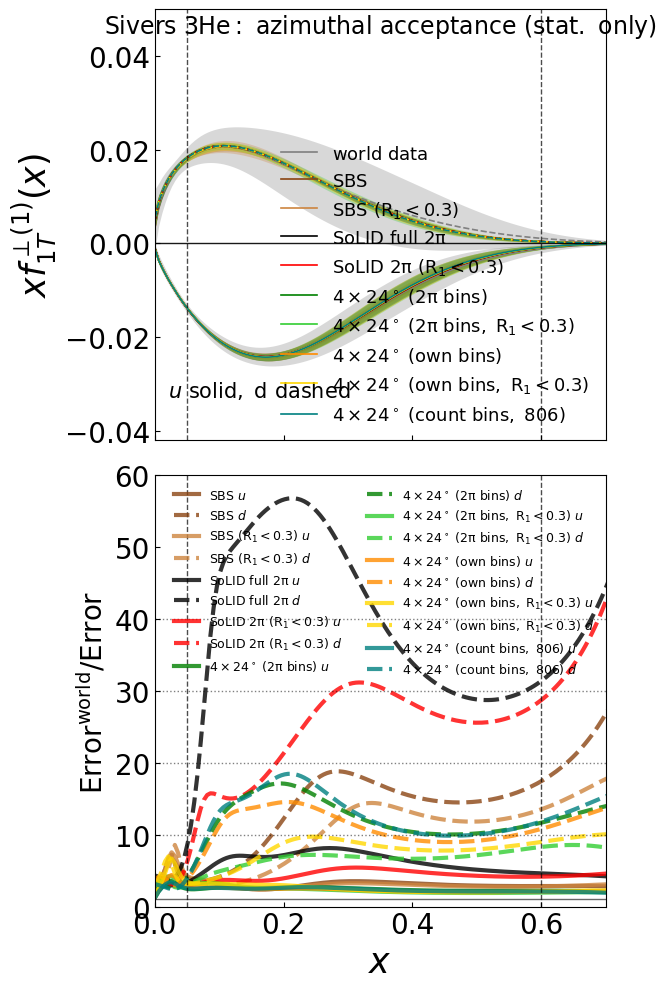

In [7]:
band_plot('', 'sivers-phicompare.pdf',
          r'$\rm Sivers~3He:~azimuthal~acceptance~(stat.~only)$');

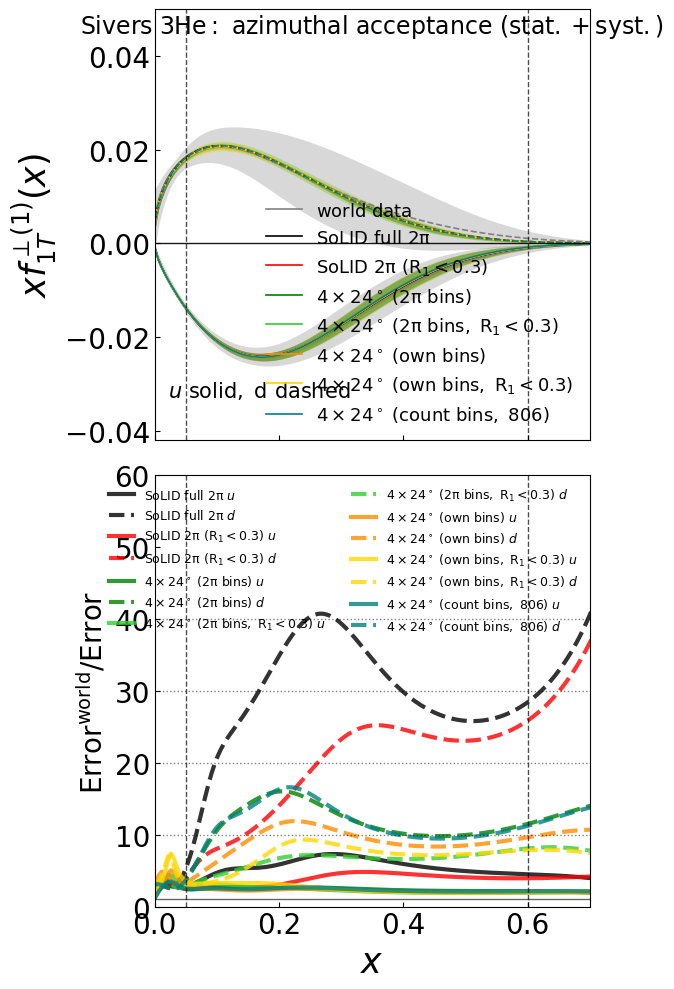

In [8]:
band_plot('syst', 'sivers-phicompare-syst.pdf',
          r'$\rm Sivers~3He:~azimuthal~acceptance~(stat.+syst.)$');

## Uncertainty ratio at representative $x$

Same information as the bottom panels, tabulated across the SoLID coverage.

In [9]:
XPTS = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

rows = []
for suffix, sname in [('', 'stat'), ('syst', 'stat+syst')]:
    ref = f1t[REF + suffix]
    for run, cfg in runs_for(suffix):
        if run == REF:
            continue
        d = f1t[run + suffix]
        for q, lab in [('Exu', 'u'), ('Exd', 'd')]:
            r = {'variant': sname, 'run': run, 'quark': lab}
            for x in XPTS:
                j = int(np.argmin(np.abs(d['x'].values - x)))
                r[f'x={x}'] = round(ref[q].values[j] / d[q].values[j], 2)
            rows.append(r)
print('Error^world / Error  (larger = SoLID better; 20 means 20x more precise)')
pd.DataFrame(rows).set_index(['variant', 'run', 'quark'])

Error^world / Error  (larger = SoLID better; 20 means 20x more precise)


x=0.05  x=0.1  x=0.2  x=0.3  x=0.4  x=0.5  x=0.6
variant   run                 quark                                                  
stat      sbs                 u        3.98   3.15   2.60   3.53   3.24   2.92   2.86
                              d        3.42   4.17  12.43  18.58  15.41  14.60  17.35
          sbs_tmd             u        4.20   3.29   2.56   3.25   3.02   2.78   2.80
                              d        3.94   2.99   6.02  13.51  13.15  11.83  13.48
          phifull             u        3.37   6.35   7.19   7.93   6.28   5.14   4.63
                              d        8.89  46.54  56.69  47.77  34.14  28.86  31.28
          phifull_tmd         u        2.93   3.69   3.96   5.41   4.92   4.29   4.16
                              d        6.48  15.38  21.53  30.99  28.35  25.59  28.62
          phi4seg_fullbin     u        2.45   2.65   2.68   2.56   2.29   2.18   2.20
                              d        4.18  12.38  17.10  12.93  10.42  10.17  11.64
          phi4seg_fullbin_tmd u        3.18   3.17   2.51   2.22   1.97   1.89   1.95
                              d        3.02   4.94   6.94   6.99   6.65   7.13   8.28
          phi4seg             u        2.83   2.67   2.51   2.35   2.10   2.02   2.08
                              d        3.92  11.38  14.55  11.63   9.31   9.14  10.77
          phi4seg_tmd         u        3.41   3.19   2.97   2.36   2.05   1.99   2.10
                              d        3.12   4.14   8.93   9.10   7.95   7.95   8.98
          phi4seg_countbin    u        2.52   2.61   2.64   2.50   2.20   2.09   2.09
                              d        4.06  13.36  18.41  13.53  10.34  10.00  11.79
stat+syst phifull             u        2.83   4.76   5.89   7.27   5.96   4.95   4.51
                              d        5.59  20.98  35.17  39.21  30.04  25.87  28.35
          phifull_tmd         u        2.43   2.74   3.07   4.69   4.59   4.08   3.94
                              d        4.13   8.11  14.22  23.44  24.70  23.08  25.80
          phi4seg_fullbin     u        2.45   2.60   2.65   2.54   2.28   2.17   2.17
                              d        3.98  10.76  16.03  12.59  10.17   9.94  11.47
          phi4seg_fullbin_tmd u        3.12   3.15   2.59   2.23   1.97   1.89   1.94
                              d        2.86   4.36   6.77   6.98   6.62   7.06   8.08
          phi4seg             u        2.89   2.38   2.41   2.33   2.06   1.96   1.99
                              d        3.38   6.35  11.59  10.34   8.60   8.49   9.63
          phi4seg_tmd         u        3.48   3.28   3.13   2.35   2.02   1.94   2.02
                              d        3.06   3.59   8.47   8.46   7.28   7.28   7.85
          phi4seg_countbin    u        2.50   2.53   2.58   2.47   2.18   2.08   2.12
                              d        3.82  11.18  16.38  12.84   9.90   9.60  11.20

## Parameter-level summary

The Sivers fit has no tensor-charge analogue of $g_T$, so the compact summary is
the replica spread of the fitted parameters themselves. `kt2` is the one to
watch: it sets the transverse-momentum width, which is what an azimuthal
acceptance cut degrades most directly.

**Do not read the "vs world" parameter column as a precision comparison.**
`fitworld()` and `fitsim()` fix *different* parameters: the world fit floats 7
(`fix=[F,F,F,T,F,F,F,T,T,T,F]` — `cu`, `cd`, `Nub`, `Ndb` held), while the SoLID
fits float 9 (only `Nub`, `Ndb` held). Letting `cu`/`cd` float gives the SoLID
replicas extra freedom that inflates individual parameter spreads, which is why
`Nu` comes out with a *larger* std than world's despite SoLID being far more
precise on the actual observable. The band ratios above (which marginalise over
the whole parameter set) are the meaningful comparison against world; the
run-to-run column below, which compares like-configured `fitsim` outputs to each
other, is the meaningful one for the φ-cut effect.

In [10]:
COLS = ['Nu', 'au', 'bu', 'Nd', 'ad', 'bd', 'kt2']

for suffix, sname in [('', 'stat'), ('syst', 'stat+syst')]:
    print(f'--- {sname}: std(world)/std, larger = better '
          f'(NOT a precision comparison -- different params fixed, see above) ---')
    ref = par[REF + suffix]
    for run, cfg in runs_for(suffix):
        cells = [f'{c}={ref[c].std()/par[run+suffix][c].std():.2f}' for c in COLS]
        print(f'  {run:18s} ' + '  '.join(cells))
    print()

for suffix, sname in [('', 'stat'), ('syst', 'stat+syst')]:
    print(f'--- {sname}: replica-std ratio to SoLID full-2pi '
          f'(like-for-like -- this is the phi-cut effect) ---')
    ref = par['phifull' + suffix]
    for run, cfg in runs_for(suffix):
        if run == REF:
            continue
        cells = [f'{c}={par[run+suffix][c].std()/ref[c].std():.3f}' for c in COLS]
        print(f'  {run:18s} ' + '  '.join(cells))
    print()

print('--- systematics penalty: std(stat+syst) / std(stat) ---')
for run, cfg in runs_for('syst'):
    if run == REF:
        continue          # world has no syst variant; SBS is already excluded
    cells = [f'{c}={par[run+"syst"][c].std()/par[run][c].std():.2f}' for c in COLS]
    print(f'  {run:18s} ' + '  '.join(cells))
print()
print('Ratios marginally below 1.0 are 500-replica sampling noise (3.2%), not a')
print('real reduction -- adding systematics cannot shrink an error. Use them as')
print('the scale for how much of the near-1.0 numbers above is meaningful.')

--- stat: std(world)/std, larger = better (NOT a precision comparison -- different params fixed, see above) ---
  world              Nu=1.00  au=1.00  bu=1.00  Nd=1.00  ad=1.00  bd=1.00  kt2=1.00
  sbs                Nu=0.23  au=1.76  bu=1.00  Nd=1.76  ad=2.91  bd=4.03  kt2=2.00
  sbs_tmd            Nu=0.24  au=1.70  bu=1.06  Nd=1.75  ad=3.00  bd=3.36  kt2=2.25
  phifull            Nu=0.29  au=2.39  bu=1.29  Nd=3.00  ad=5.17  bd=5.62  kt2=18.58
  phifull_tmd        Nu=0.28  au=1.94  bu=1.27  Nd=2.73  ad=4.06  bd=5.27  kt2=5.32
  phi4seg_fullbin    Nu=0.20  au=1.30  bu=0.90  Nd=1.90  ad=3.46  bd=3.28  kt2=4.62
  phi4seg_fullbin_tmd Nu=0.21  au=1.61  bu=0.85  Nd=1.35  ad=2.68  bd=2.66  kt2=2.11
  phi4seg            Nu=0.20  au=1.34  bu=0.87  Nd=1.70  ad=3.63  bd=2.94  kt2=3.31
  phi4seg_tmd        Nu=0.20  au=1.40  bu=0.85  Nd=1.45  ad=2.76  bd=2.85  kt2=2.54
  phi4seg_countbin   Nu=0.19  au=1.27  bu=0.86  Nd=1.84  ad=3.35  bd=3.17  kt2=4.51

--- stat+syst: std(world)/std, larger = bette